# Region inspector — per-region view of the hybrid delivery

One figure per scope region: the delivered bank lines on the map (QGIS colour contract: greens = measured, darker = newer; browns = predicted, darker = later; purple = VVR family; fill = preferred model) next to the distance-to-centreline time series.

Two uses:
1. **Far-bank / wrong-bank triage** — `farbank_candidates()` ranks regions where the segmentation model intermittently drew a line on the wrong bank. The time-series panel shows it as a bimodal gap (several lines on one date, far apart) or a jump between dates.
2. **Resolution** — the map shows how much bank-position variation a single per-region scalar collapses; the basis for the R>1 work.


In [1]:
%load_ext autoreload
%autoreload 2

import warnings

warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt

from src.erosion.region_inspector import RegionInspector

ri = RegionInspector()  # defaults to the 20260819-hybrid experiment

## Far-bank candidates

Two signatures, scored per region:
* `multiline_gap` — one survey date delivered several lines whose median distances differ by >25 m and >1.5×: two different banks drawn for one moment. These are the recoverable cases — drop the artefact line, keep the survey.
* `temporal_jump` — the year-collapsed nearest-line series still moves >50 m/yr: a whole survey is on the wrong bank (either bank — there are near-bank cases where a line hugs the centreline).


In [2]:
cand = ri.farbank_candidates()
print(f'{len(cand)} flagged regions '
      f'of {ri.line_stats.location_id.nunique()} measurable')
cand['flag'].value_counts()

1185 flagged regions of 11517 measurable


flag
multiline_gap                  672
temporal_jump                  449
multiline_gap+temporal_jump     64
Name: count, dtype: int64

In [3]:
cand.head(15).round(1)

,n_dates,n_multiline_dates,max_multiline_gap_m,max_multiline_ratio,max_abs_v,model,flag,score
location_id,,,,,,,,
rijn_r_2680_2690,7,2,301.0,7.2,67.0,segmentation,multiline_gap+temporal_jump,368.0
rijn_l_5590_5600,6,1,121.1,2.3,220.9,segmentation,multiline_gap+temporal_jump,342.0
rijn_l_6020_6030,8,8,177.0,2.8,160.9,segmentation,multiline_gap+temporal_jump,337.9
rijn_l_5980_5990,8,5,153.2,2.6,165.9,segmentation,multiline_gap+temporal_jump,319.1
rijn_l_5210_5220,9,1,141.2,1.8,175.1,segmentation,multiline_gap+temporal_jump,316.4
rijn_l_6000_6010,8,4,146.0,2.6,168.1,segmentation,multiline_gap+temporal_jump,314.1
rijn_l_5200_5210,9,8,152.5,1.9,156.4,segmentation,multiline_gap+temporal_jump,308.9
rijn_r_9810_9820,4,3,150.9,1.8,151.6,segmentation,multiline_gap+temporal_jump,302.5
rijn_l_5990_6000,8,3,125.5,2.3,173.7,segmentation,multiline_gap+temporal_jump,299.2


### Export for QGIS
Scope polygons of the flagged regions, with the scores as fields — load next to `scope_coverage` and click through with the same location ids used here.

In [4]:
import geopandas as gpd

out = ri.cfg.data_dir / '02_processed/hybrid/farbank_candidates.gpkg'
flagged = gpd.GeoDataFrame(
    cand.round(1),
    geometry=ri.geometry.polygons.reindex(cand.index).values,
    crs=28992,
).dropna(subset=['geometry'])
flagged.to_file(out, layer='farbank_candidates', driver='GPKG')
print(f'wrote {len(flagged)} polygons to {out}')

wrote 1185 polygons to /Users/admin/Documents/work/Moraine/oevererosie/wocu-oevererosie/data/02_processed/hybrid/farbank_candidates.gpkg


## The two artefact shapes

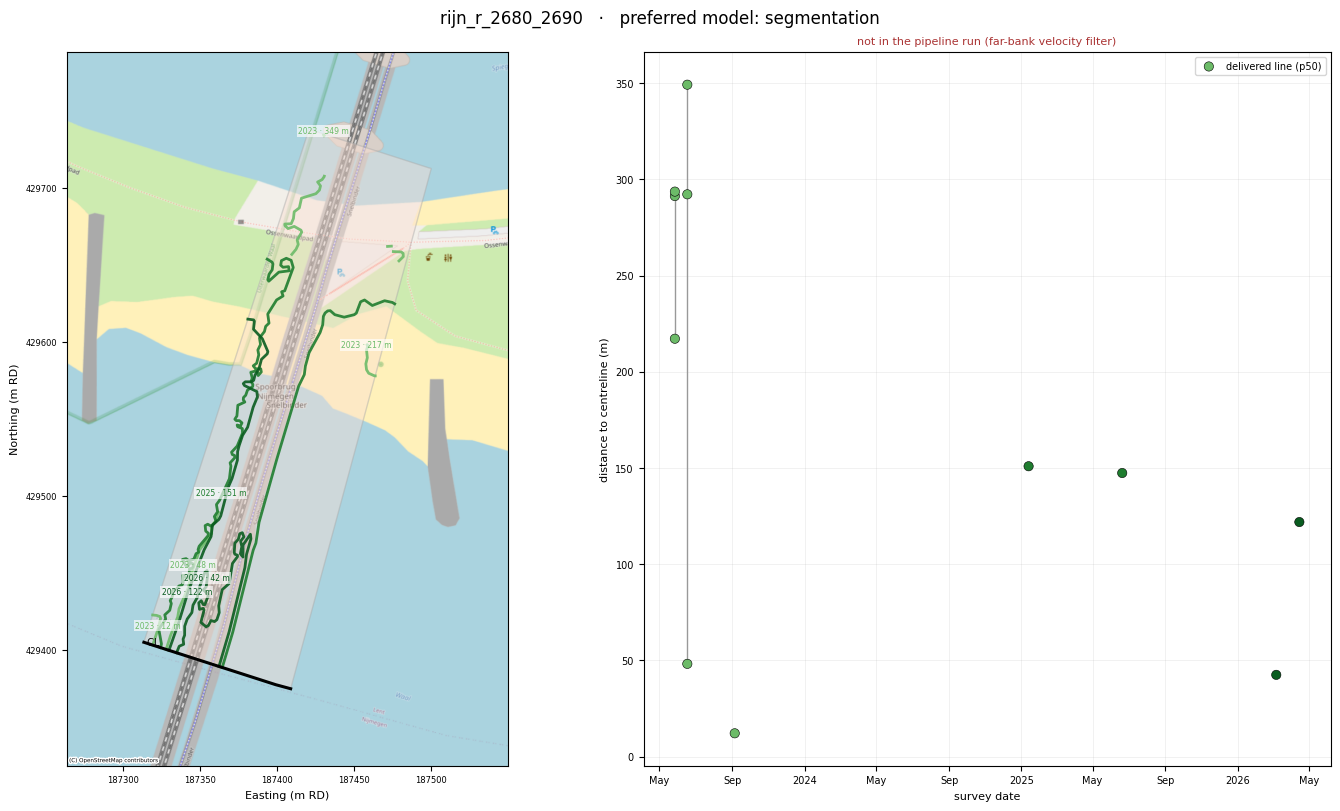

In [5]:
worst_multi = cand[cand['flag'].str.startswith('multiline')].index[0]
fig = ri.inspect(worst_multi)
plt.show()

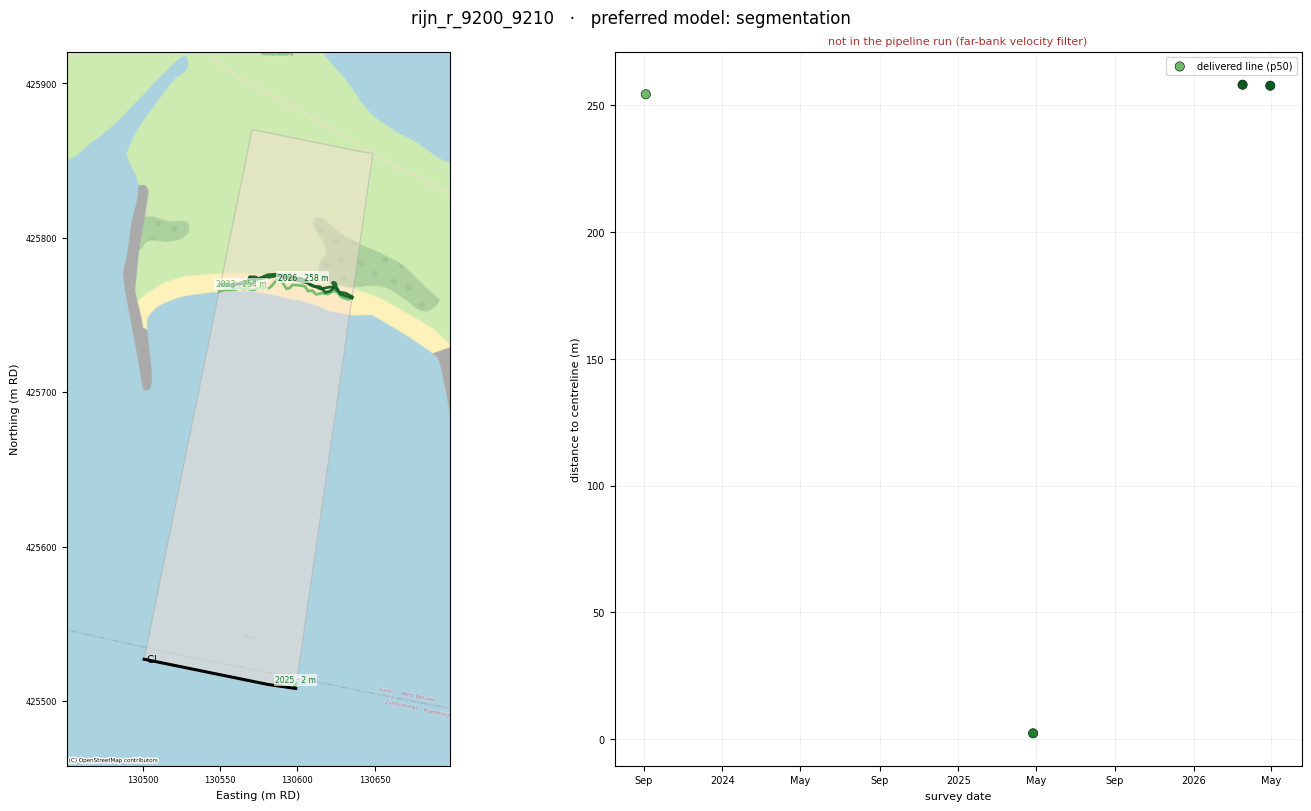

In [6]:
worst_jump = cand[cand['flag'] == 'temporal_jump'].index[0]
fig = ri.inspect(worst_jump)
plt.show()

## Healthy regions, for contrast

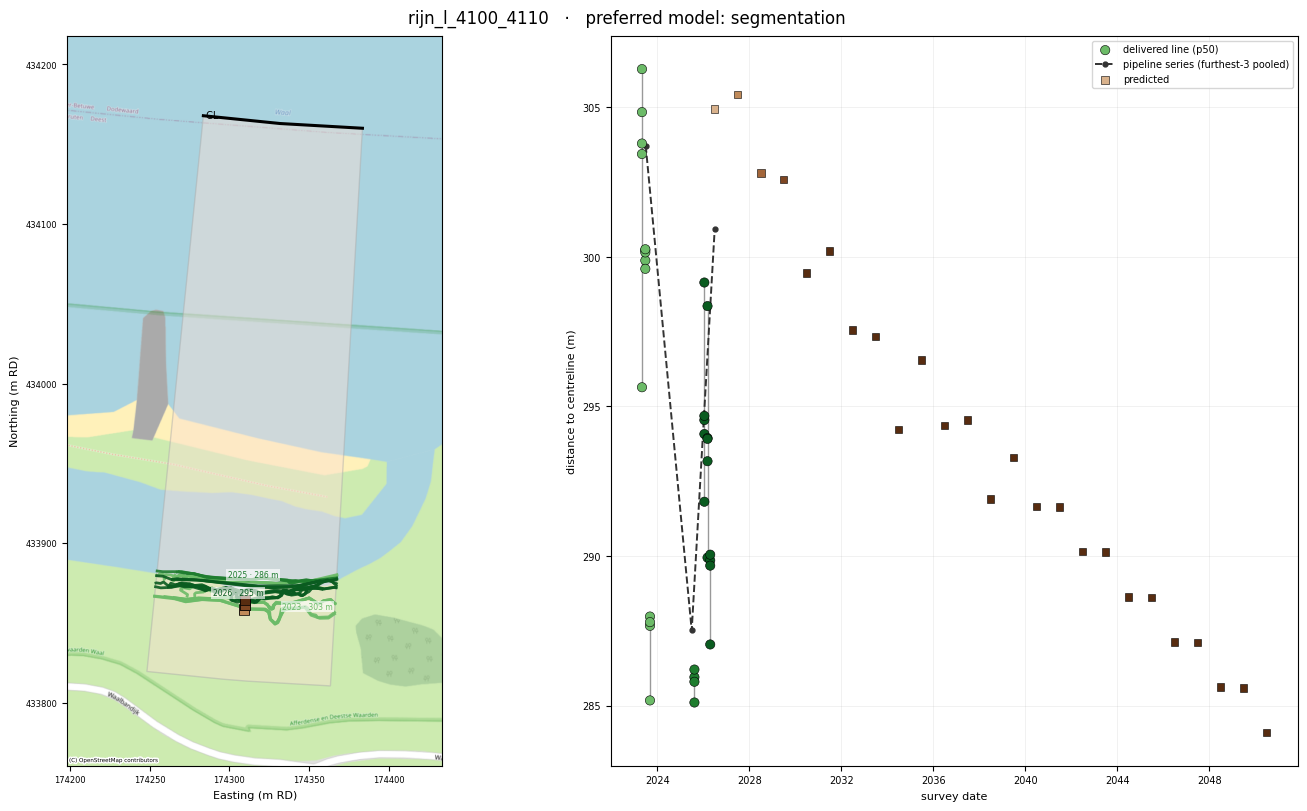

In [7]:
stats = ri.line_stats
healthy = stats[~stats.location_id.isin(cand.index)]
sam_ok = (healthy[healthy['model'] == 'segmentation']
          .groupby('location_id').size().idxmax())
fig = ri.inspect(sam_ok)
plt.show()

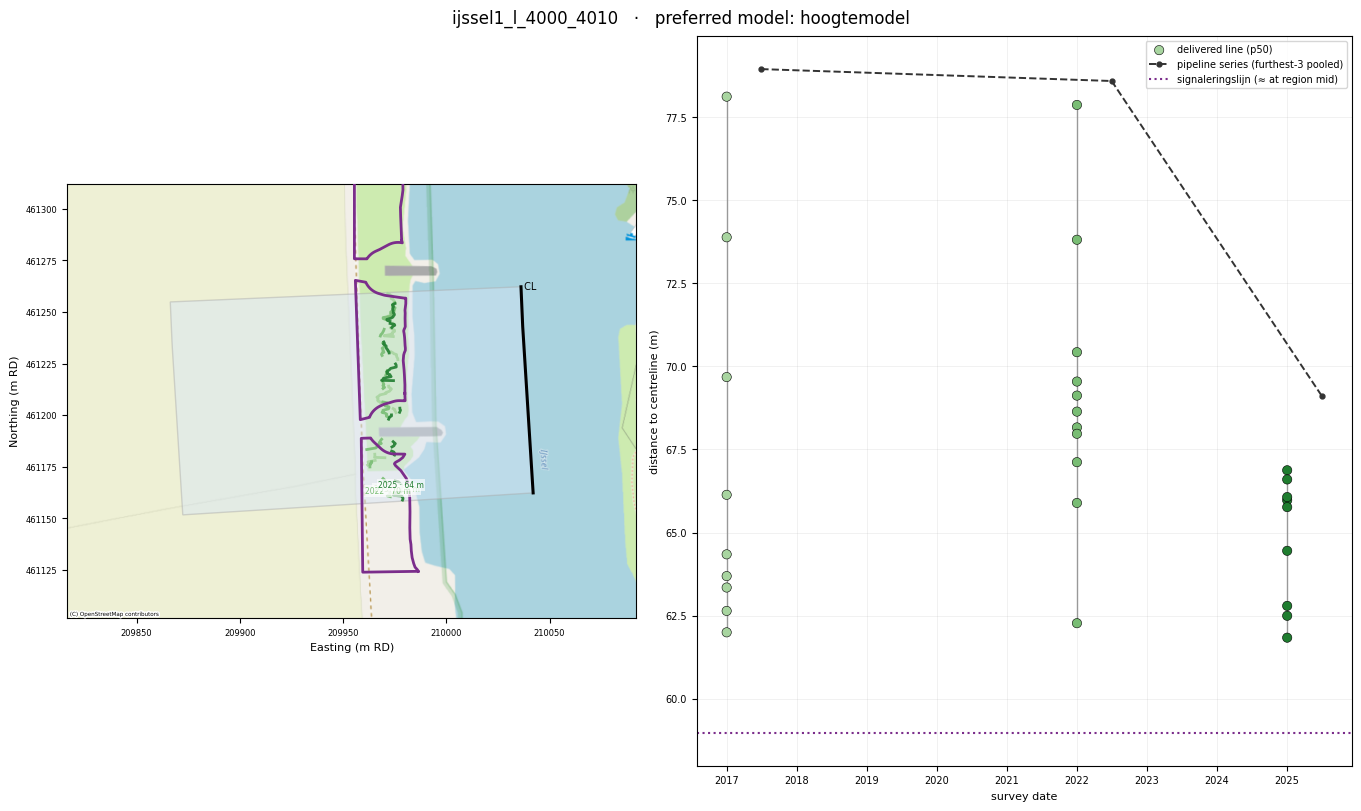

In [8]:
hm_ok = (healthy[healthy['model'] == 'hoogtemodel']
         .groupby('location_id').size().idxmax())
fig = ri.inspect(hm_ok)
plt.show()

## Inspect any region
Drop in a `location_id` — e.g. from QGIS (`scope_coverage`, `farbank_candidates`) or the prediction dots layer.

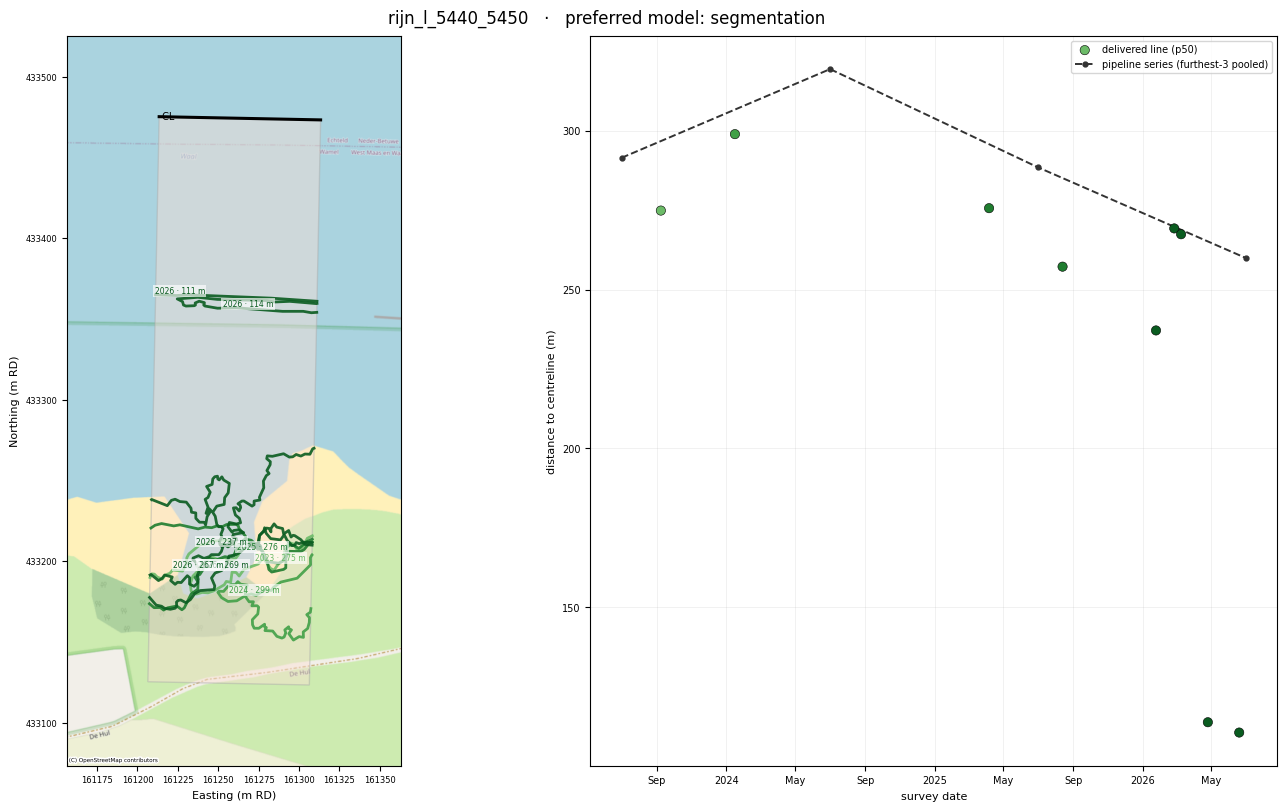

In [9]:
fig = ri.inspect('rijn_l_5440_5450')
plt.show()